In [1]:
import pandas as pad

In [2]:
import requests

In [3]:
from bs4 import BeautifulSoup

In [5]:
!pip install selenium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.7/475.7 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 5.1 MB/s eta 0:00:00


In [6]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
import pandas as pd
import time
def web_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--verbose")
    options.add_argument('--no-sandbox')
    options.add_argument('--headless')
    options.add_argument('--disable-gpu')
    options.add_argument("--window-size=1920, 1200")
    options.add_argument('--disable-dev-shm-usage')
    driver = webdriver.Chrome(options=options)
    return driver

driver =web_driver()

'''# Setup WebDriver
service = Service("D:/Data_Science/DS_Projects/stock_market/chromedriver-win64/chromedriver.exe")
options = Options()
options.add_argument('--headless')  # Run in headless mode
driver = webdriver.Chrome(service=service, options=options)
'''

# Construct URL with date range
start_date = "2015-01-01"
end_date = "2022-12-31"
url = f"https://finance.yahoo.com/quote/RELIANCE.NS/history?period1={int(time.mktime(time.strptime(start_date, '%Y-%m-%d')))}&period2={int(time.mktime(time.strptime(end_date, '%Y-%m-%d')))}&interval=1d&filter=history&frequency=1d&includeAdjustedClose=true"

# Open page
driver.get(url)

# Wait for the page to load
time.sleep(10)

# Extract data
rows = driver.find_elements(By.CSS_SELECTOR, 'table tbody tr')
data = []
for row in rows:
    columns = row.find_elements(By.TAG_NAME, 'td')
    if columns:
        data.append([col.text for col in columns])

# Close the driver
driver.quit()

# Convert to DataFrame
df = pd.DataFrame(data, columns=["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"])
print("Reliance Data Scraped Successfully")

Reliance Data Scraped Successfully


In [7]:
# Save to CSV
df.to_csv("reliance_historical_data.csv", index=False)

# Print DataFrame to see in table format
print(df)

              Date      Open      High       Low     Close Adj Close  \
0     Dec 30, 2022  2,349.13  2,378.57  2,345.43  2,351.06  2,342.79   
1     Dec 29, 2022  2,332.42  2,352.63  2,331.04  2,347.47  2,339.20   
2     Dec 28, 2022  2,342.57  2,353.46  2,327.34  2,348.53  2,340.26   
3     Dec 27, 2022  2,335.19  2,352.54  2,321.57  2,348.76  2,340.49   
4     Dec 26, 2022  2,321.11  2,346.27  2,300.48  2,329.70  2,321.50   
...            ...       ...       ...       ...       ...       ...   
1980   Jan 7, 2015    382.69    392.61    382.65    390.56    368.33   
1981   Jan 6, 2015    397.73    399.11    380.36    382.24    360.48   
1982   Jan 5, 2015    404.59    407.29    399.61    400.41    377.62   
1983   Jan 2, 2015    406.01    409.64    404.27    404.84    381.80   
1984   Jan 1, 2015    405.19    407.79    403.98    405.92    382.81   

          Volume  
0      3,644,738  
1      3,465,324  
2      3,729,696  
3      2,881,635  
4      2,995,121  
...          ...  
19

In [8]:
#Removing the "Adj Close" column from dataset
Reliance=df.drop(['Adj Close'],axis=1)
Reliance

,Date,Open,High,Low,Close,Volume
0,"Dec 30, 2022","2,349.13","2,378.57","2,345.43","2,351.06","3,644,738"
1,"Dec 29, 2022","2,332.42","2,352.63","2,331.04","2,347.47","3,465,324"
2,"Dec 28, 2022","2,342.57","2,353.46","2,327.34","2,348.53","3,729,696"
3,"Dec 27, 2022","2,335.19","2,352.54","2,321.57","2,348.76","2,881,635"
4,"Dec 26, 2022","2,321.11","2,346.27","2,300.48","2,329.70","2,995,121"
...,...,...,...,...,...,...
1980,"Jan 7, 2015",382.69,392.61,382.65,390.56,"10,360,156"
1981,"Jan 6, 2015",397.73,399.11,380.36,382.24,"9,313,990"
1982,"Jan 5, 2015",404.59,407.29,399.61,400.41,"5,051,970"
1983,"Jan 2, 2015",406.01,409.64,404.27,404.84,"3,665,683"


In [9]:
# Convert 'Date' column to datetime type
Reliance['Date'] = pd.to_datetime(Reliance['Date'])

In [10]:
# Set 'Date' as the index
Reliance.set_index('Date', inplace=True)

In [11]:
# Convert 'Volume' column to string and replace commas
Reliance['Volume'] = Reliance['Volume'].astype(str).str.replace(',', '')

In [12]:
# Convert columns to appropriate data types
Reliance[['Open', 'High', 'Low', 'Close', 'Volume']] = Reliance[['Open', 'High', 'Low', 'Close', 'Volume']].apply(pd.to_numeric, errors='coerce')

In [13]:
# Check for missing values
print("Missing values in each column:")
print(Reliance.isnull().sum())

Missing values in each column:
Open      1082
High      1096
Low       1058
Close     1076
Volume       9
dtype: int64


In [14]:
# Drop rows with any missing values
Reliance.dropna(inplace=True)

In [15]:
# Check for duplicates
print("Number of duplicate rows:")
print(Reliance.duplicated().sum())

Number of duplicate rows:
0


In [16]:
# Print cleaned DataFrame
print(Reliance)

              Open    High     Low   Close      Volume
Date                                                  
2020-03-30  951.45  982.72  932.62  942.17  15114933.0
2020-03-24  850.33  886.90  819.06  862.58  22867443.0
2020-03-23  837.71  868.62  800.64  808.32  20335474.0
2020-03-20  859.02  946.24  850.33  930.74  31680237.0
2020-03-19  841.28  884.16  815.77  839.08  30702005.0
...            ...     ...     ...     ...         ...
2015-01-07  382.69  392.61  382.65  390.56  10360156.0
2015-01-06  397.73  399.11  380.36  382.24   9313990.0
2015-01-05  404.59  407.29  399.61  400.41   5051970.0
2015-01-02  406.01  409.64  404.27  404.84   3665683.0
2015-01-01  405.19  407.79  403.98  405.92   1481821.0

[889 rows x 5 columns]


In [17]:
# Summary statistics
print("Summary statistics:")
print(Reliance.describe())

Summary statistics:
             Open        High         Low       Close        Volume
count  889.000000  889.000000  889.000000  889.000000  8.890000e+02
mean   578.976783  585.181822  572.834016  578.645231  8.338624e+06
std    179.975682  181.937438  177.852223  179.717824  5.359736e+06
min    373.320000  373.820000  364.110000  370.650000  1.481821e+06
25%    441.370000  446.400000  437.280000  442.130000  5.256508e+06
50%    476.370000  481.050000  471.340000  477.100000  6.919995e+06
75%    750.940000  756.020000  741.890000  748.020000  9.504043e+06
max    992.510000  999.090000  973.760000  996.900000  6.366156e+07


            Open      High       Low     Close    Volume
Open    1.000000  0.999378  0.999417  0.998726  0.058265
High    0.999378  1.000000  0.999152  0.999437  0.074759
Low     0.999417  0.999152  1.000000  0.999458  0.052663
Close   0.998726  0.999437  0.999458  1.000000  0.066541
Volume  0.058265  0.074759  0.052663  0.066541  1.000000


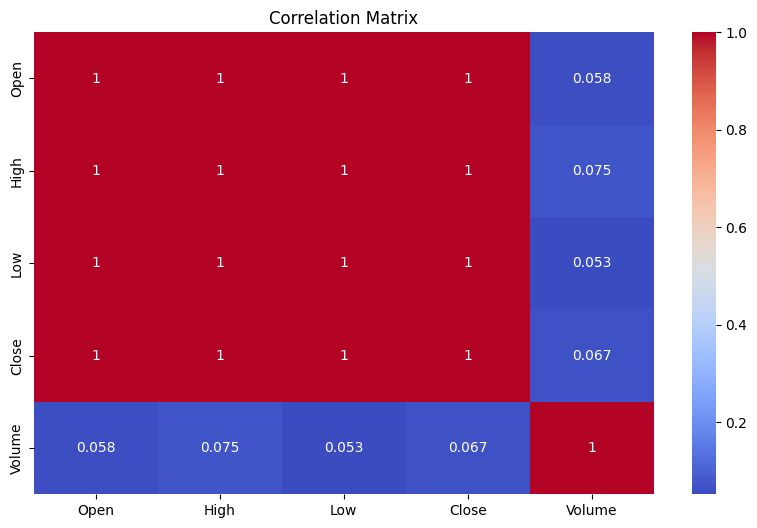

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
print(Reliance.corr())
# Correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(Reliance.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

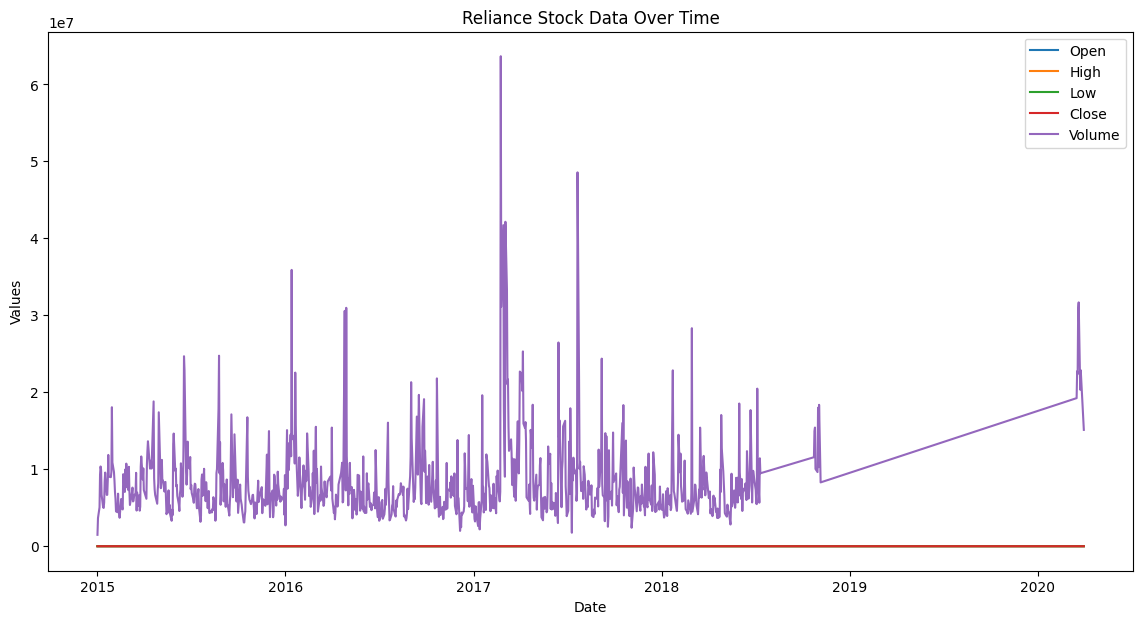

In [19]:
# Plot the entire dataset
plt.figure(figsize=(14, 7))

# Plot each column
plt.plot(Reliance['Open'], label='Open')
plt.plot(Reliance['High'], label='High')
plt.plot(Reliance['Low'], label='Low')
plt.plot(Reliance['Close'], label='Close')
plt.plot(Reliance['Volume'], label='Volume')

# Add title and labels
plt.title('Reliance Stock Data Over Time')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.show()

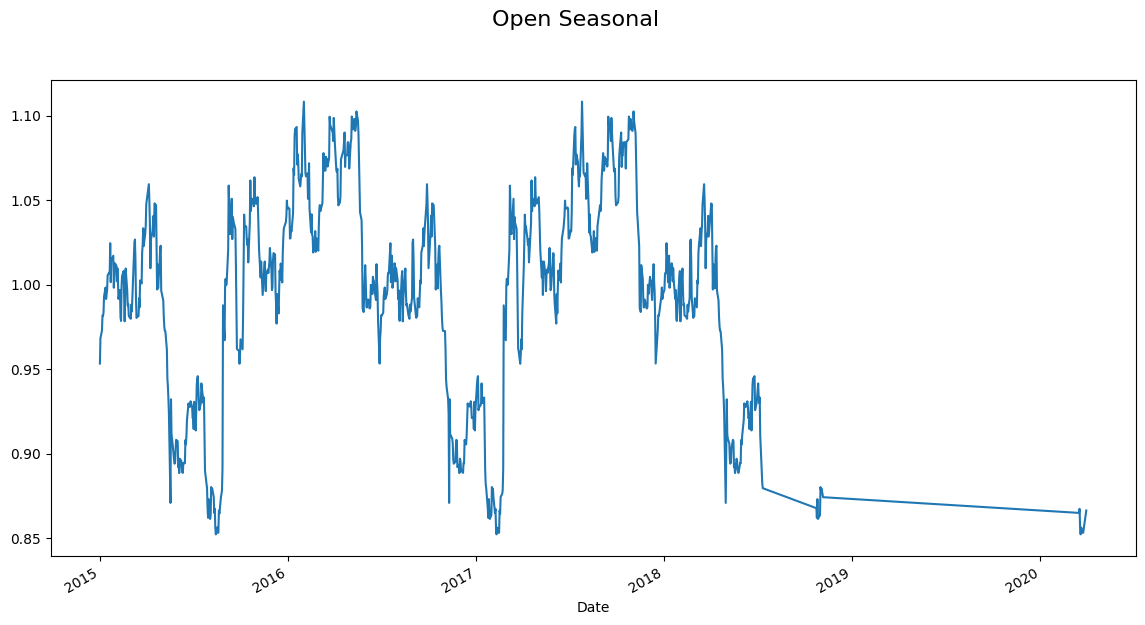

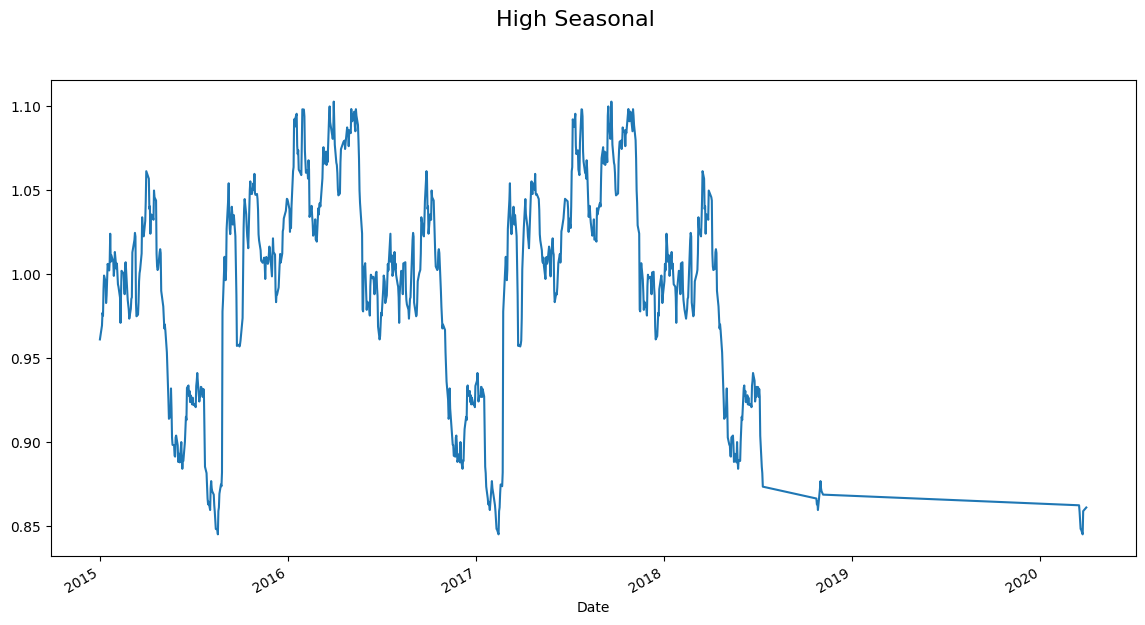

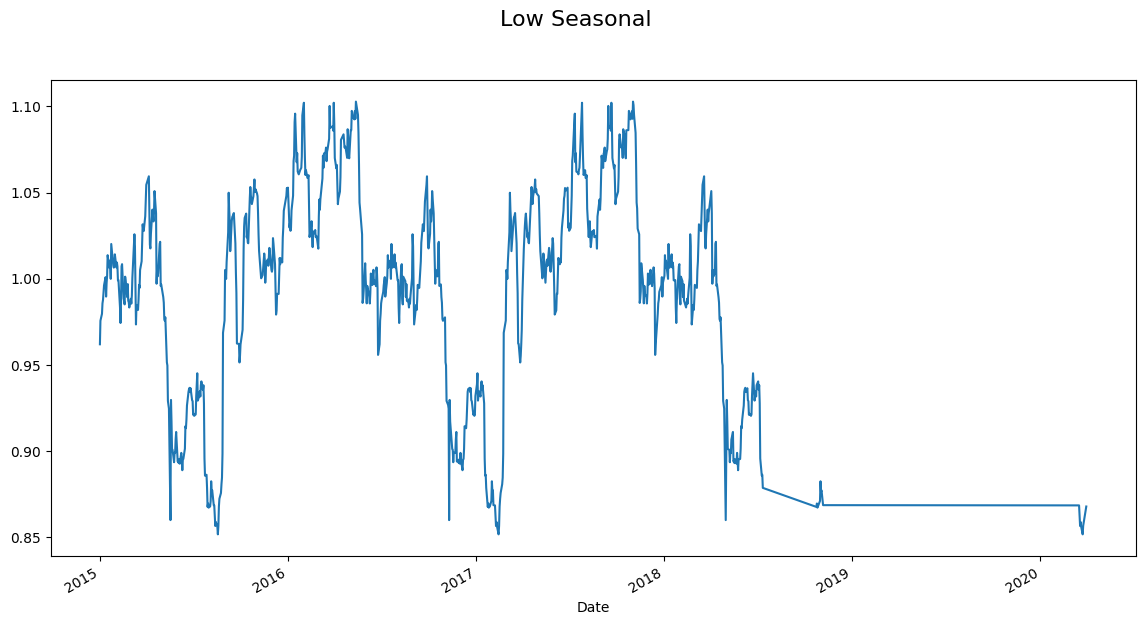

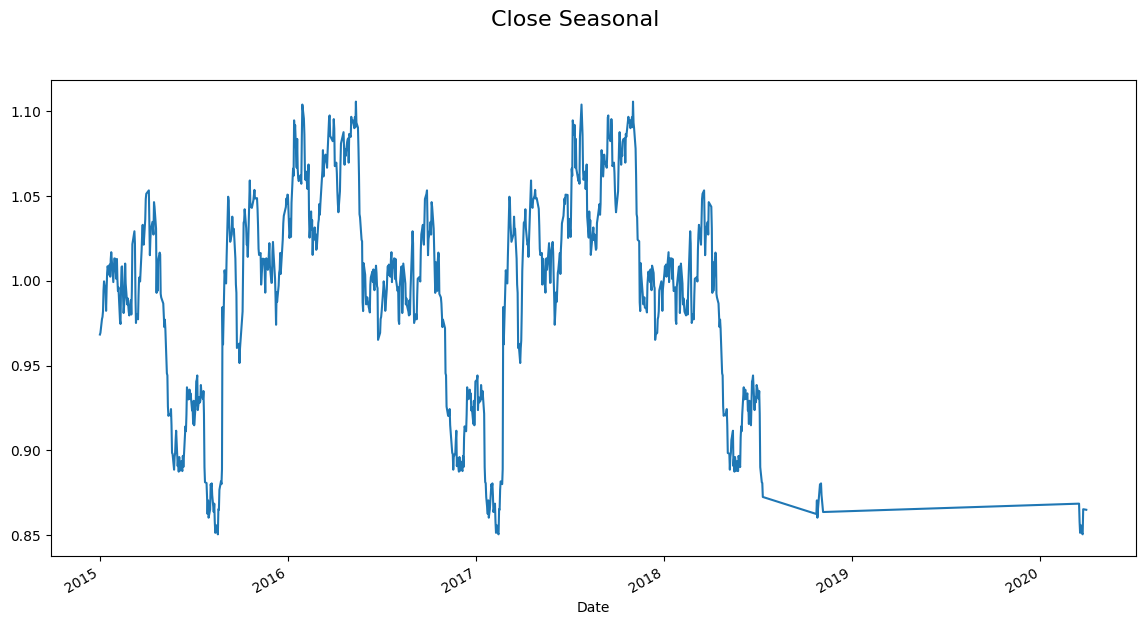

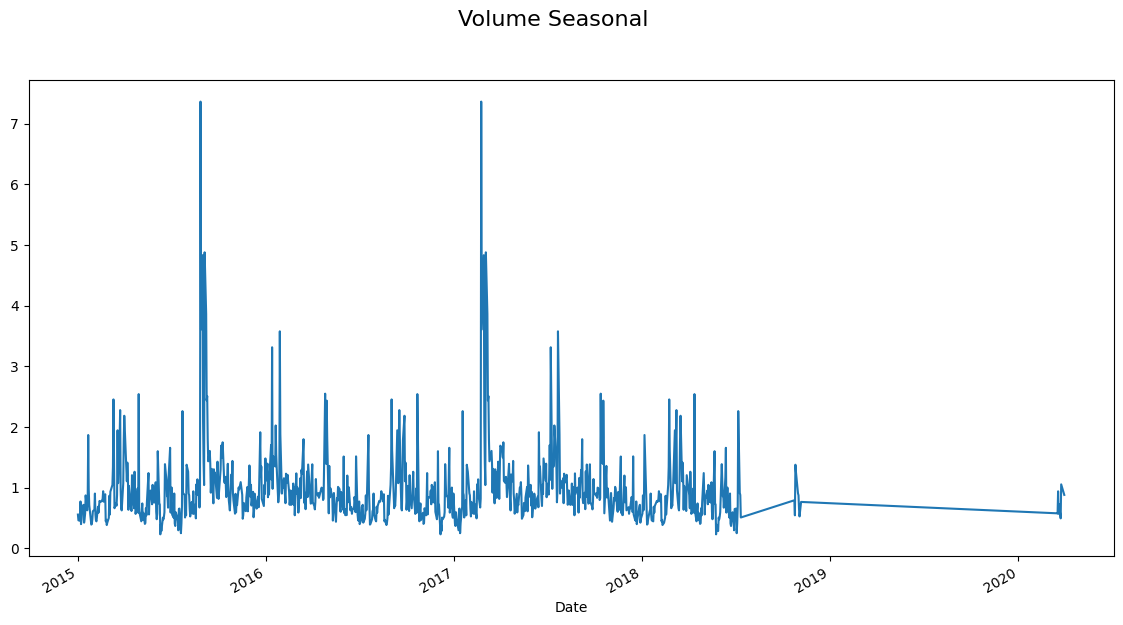

In [20]:
# Decompose and plot each column
from statsmodels.tsa.seasonal import seasonal_decompose
columns_to_decompose = ['Open', 'High', 'Low', 'Close', 'Volume']

for column in columns_to_decompose:
    plt.figure(figsize=(14, 7))
    decomposition = seasonal_decompose(Reliance[column], model='multiplicative', period=365)
    decomposition.seasonal.plot()
    plt.suptitle(f'{column} Seasonal', fontsize=16)
    plt.show()

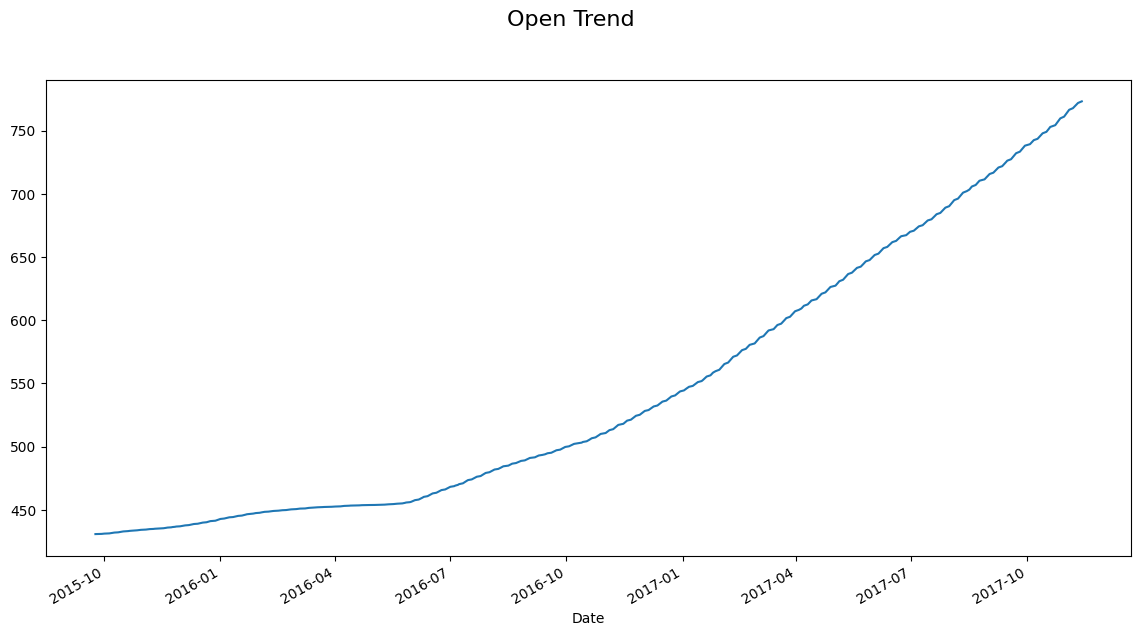

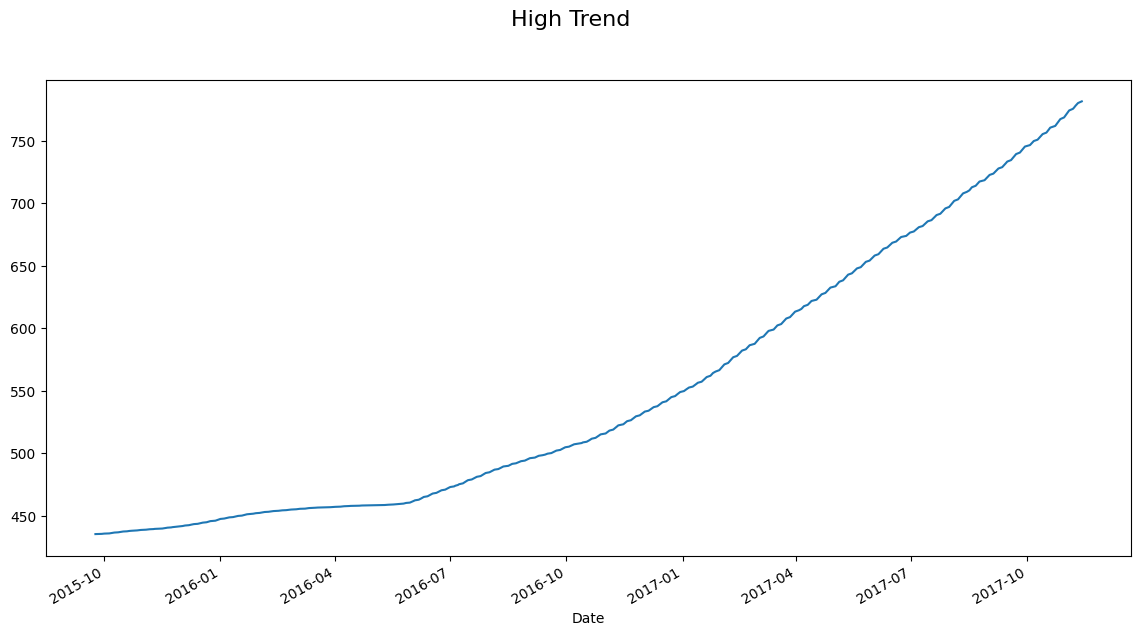

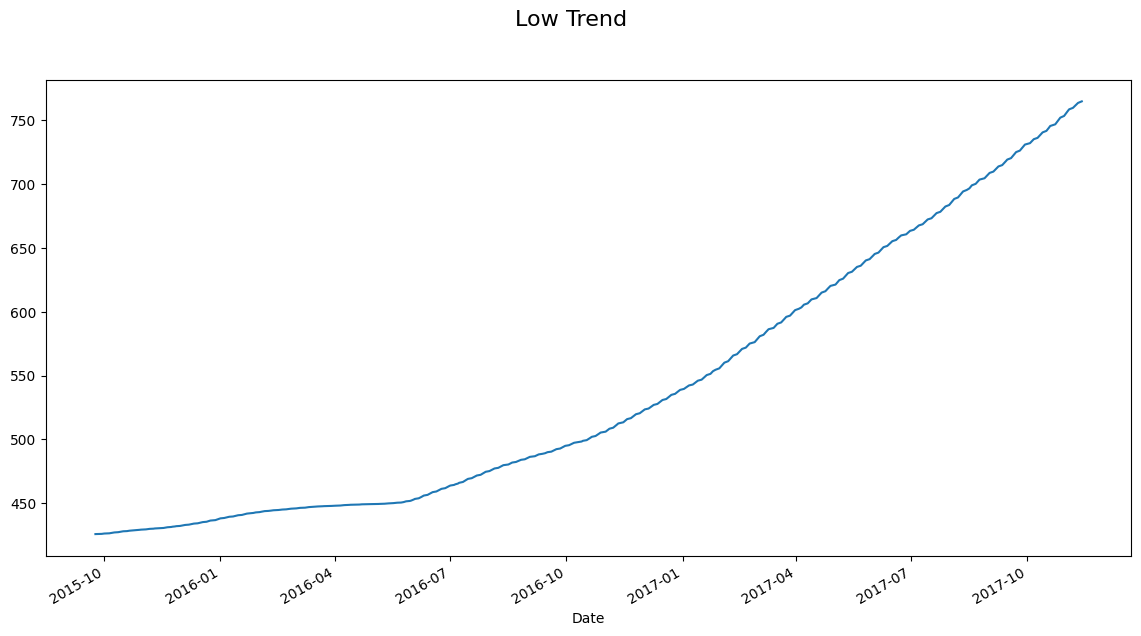

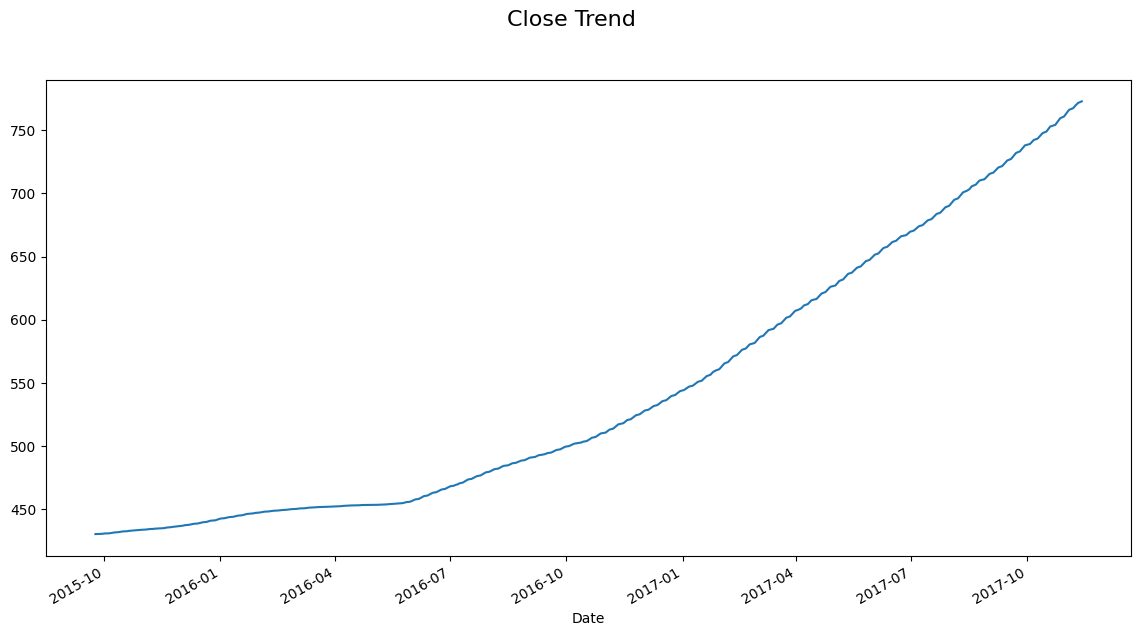

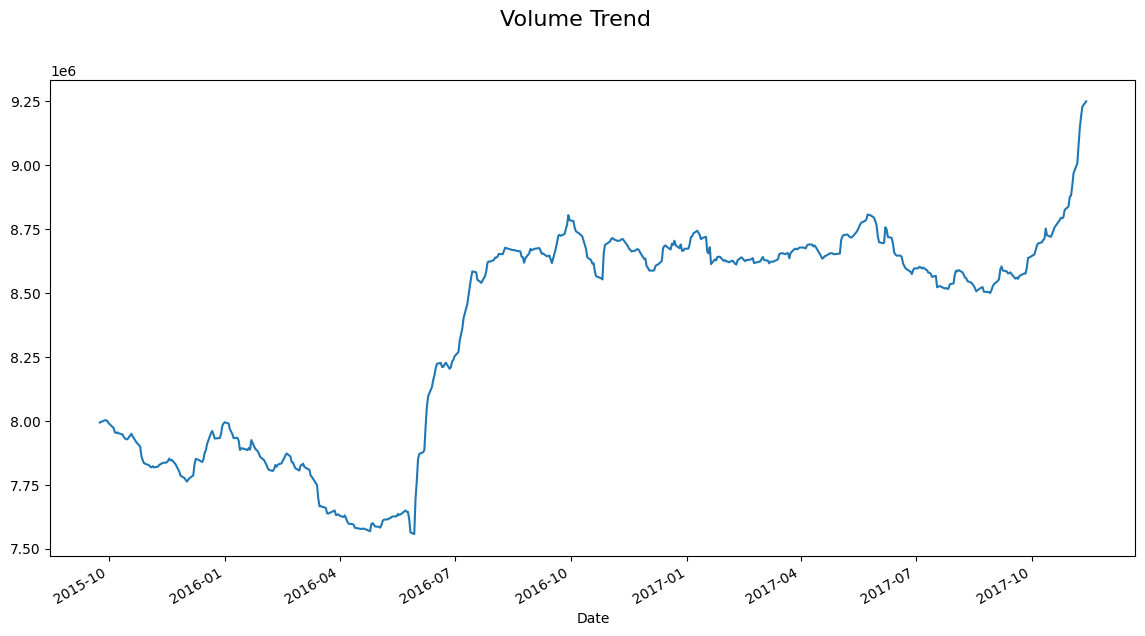

In [21]:
# Decompose and plot each column
from statsmodels.tsa.seasonal import seasonal_decompose
columns_to_decompose = ['Open', 'High', 'Low', 'Close', 'Volume']

for column in columns_to_decompose:
    plt.figure(figsize=(14, 7))
    decomposition = seasonal_decompose(Reliance[column], model='multiplicative', period=365)
    decomposition.trend.plot()
    plt.suptitle(f'{column} Trend', fontsize=16)
    plt.show()

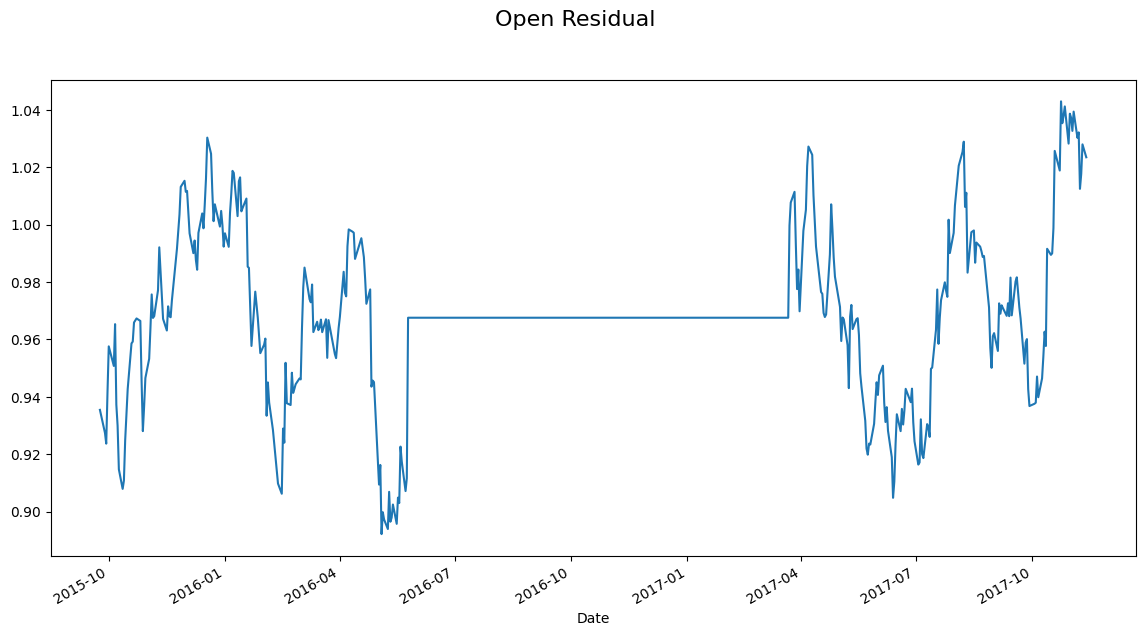

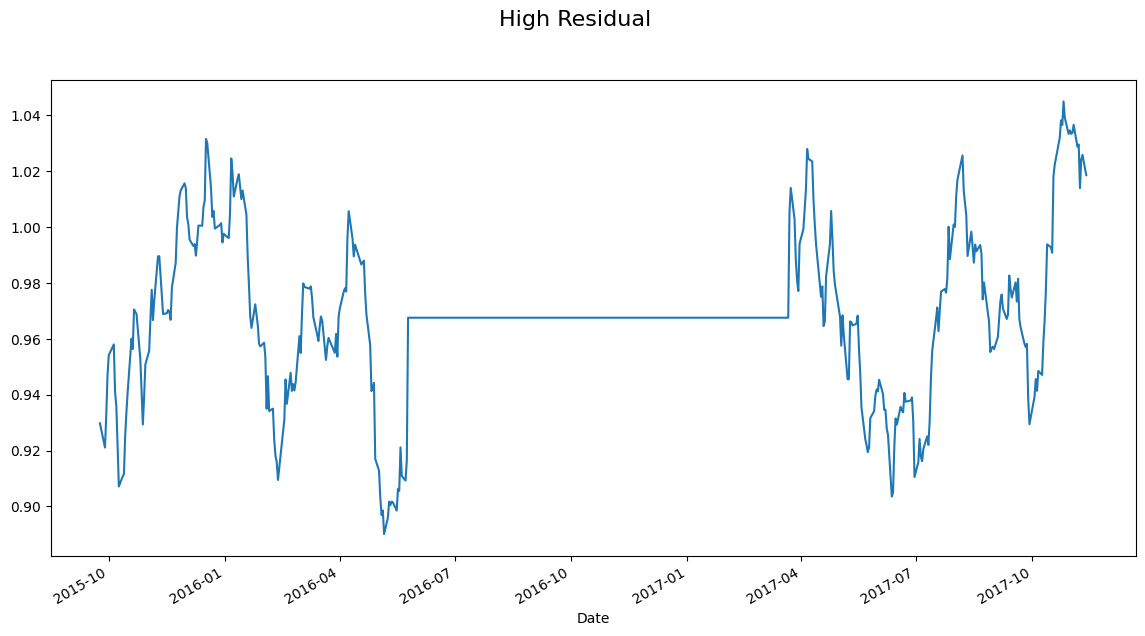

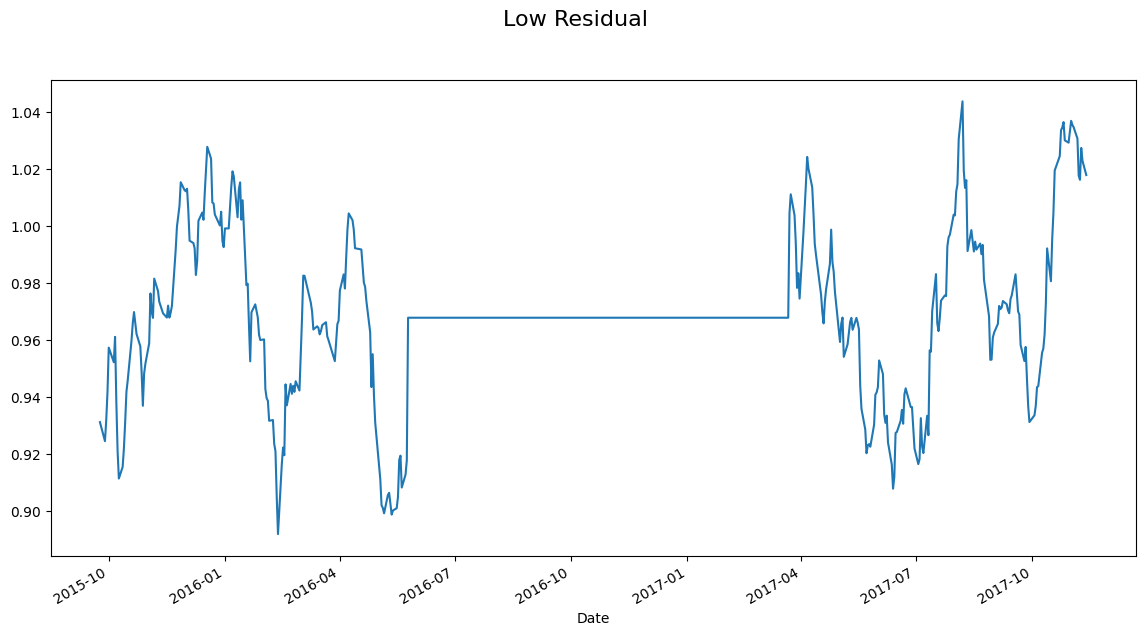

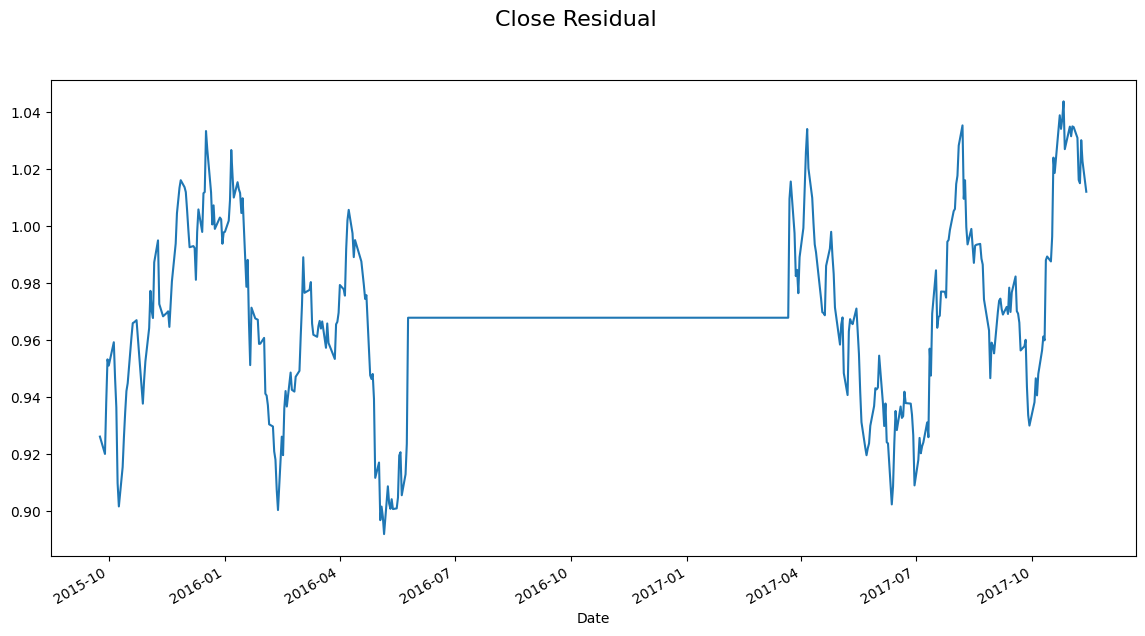

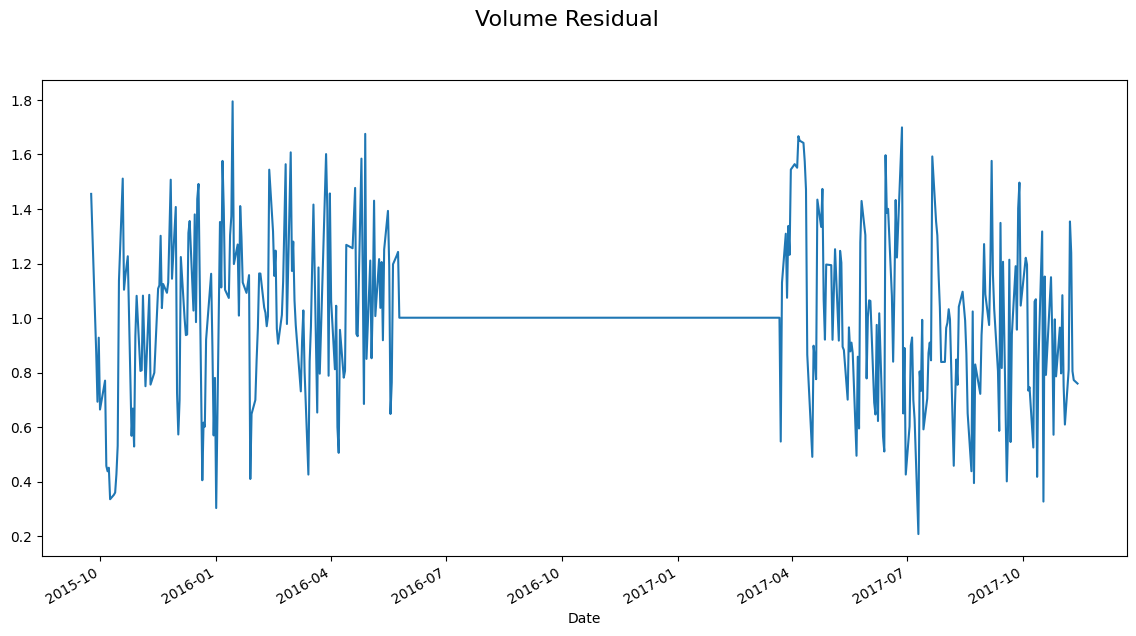

In [22]:
# Decompose and plot each column
from statsmodels.tsa.seasonal import seasonal_decompose
columns_to_decompose = ['Open', 'High', 'Low', 'Close', 'Volume']

for column in columns_to_decompose:
    plt.figure(figsize=(14, 7))
    decomposition = seasonal_decompose(Reliance[column], model='multiplicative', period=365)
    decomposition.resid.plot()
    plt.suptitle(f'{column} Residual', fontsize=16)
    plt.show()

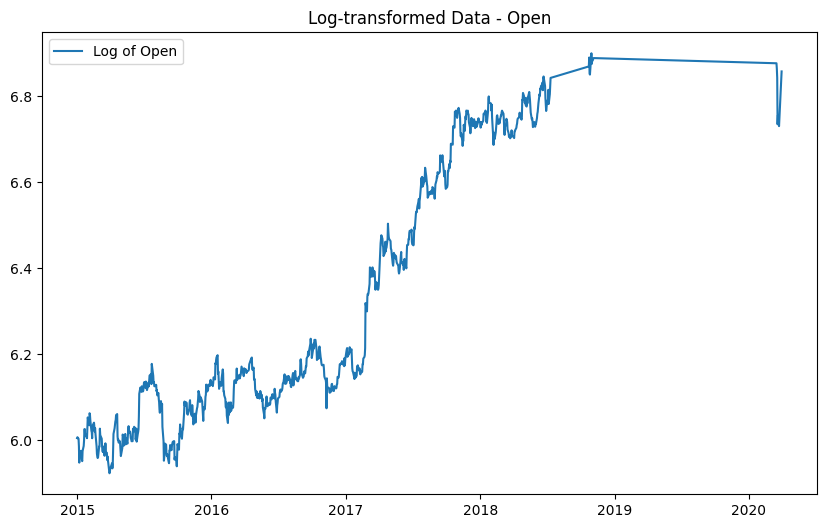

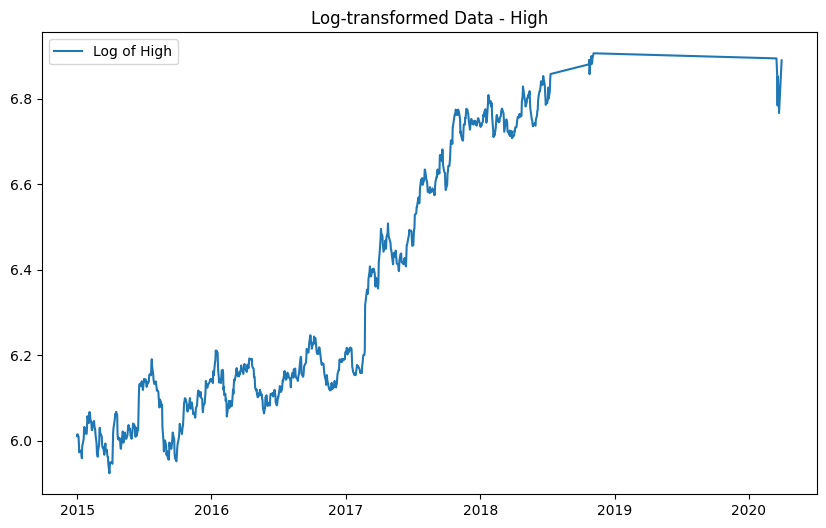

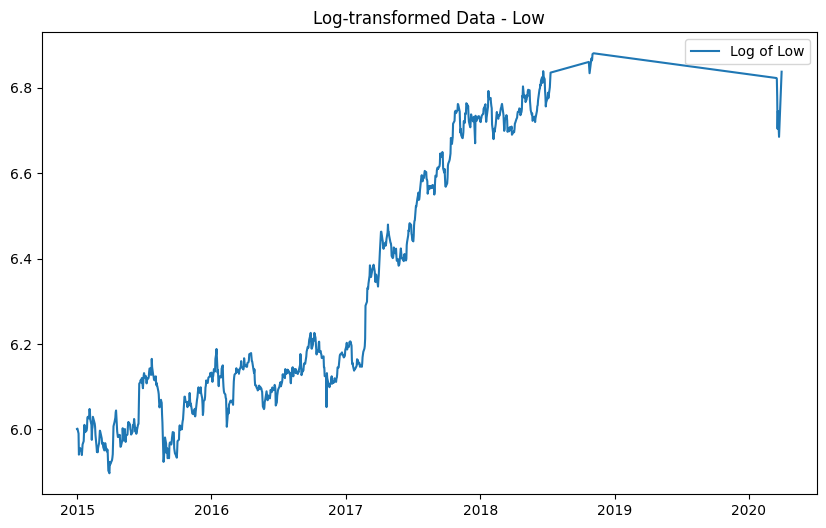

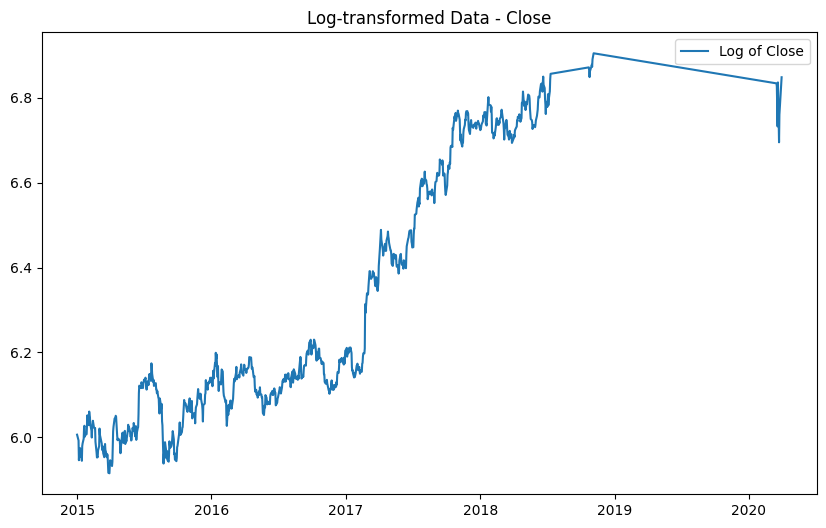

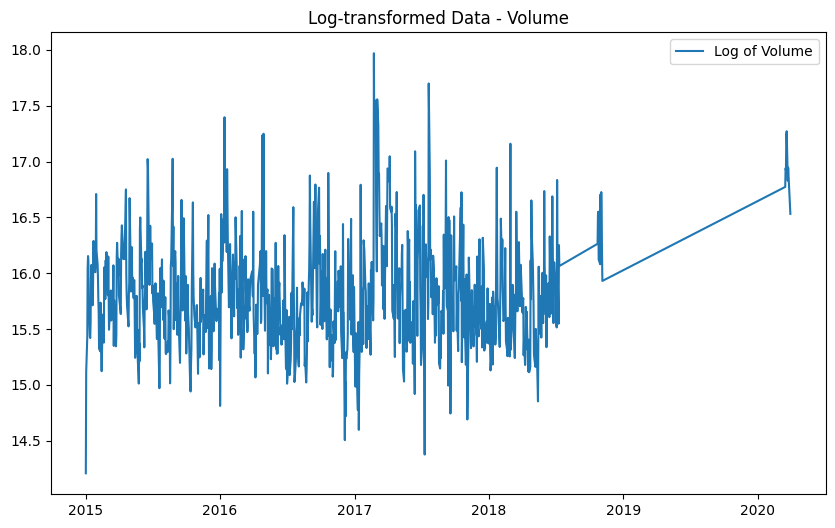

In [23]:
import numpy as np
# Select multiple columns
columns = ['Open', 'High', 'Low', 'Close', 'Volume']
log_data = np.log(Reliance[columns])

# Plot each column
for column in columns:
    plt.figure(figsize=(10, 6))
    plt.plot(log_data[column], label=f'Log of {column}')
    plt.title(f'Log-transformed Data - {column}')
    plt.legend()
    plt.show()

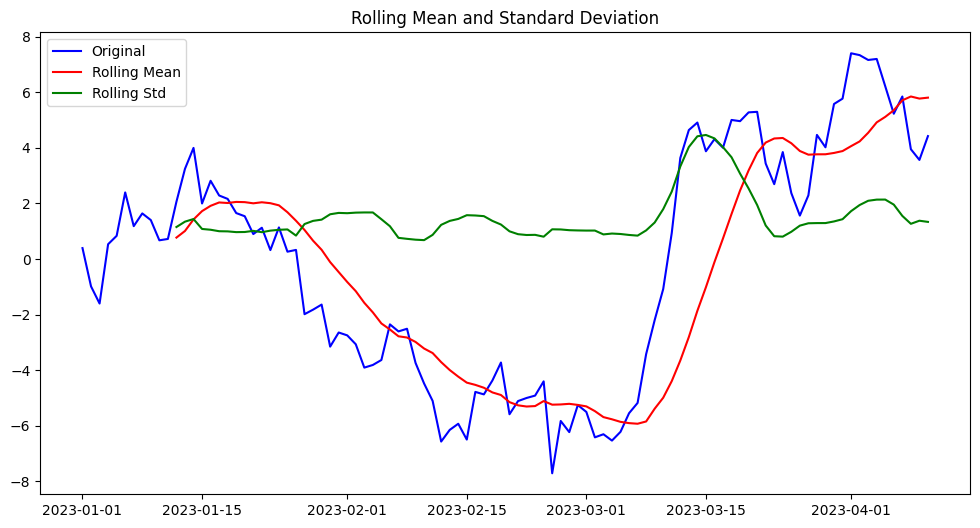

In [24]:
def test_stationarity(timeseries):

    # Compute rolling mean and standard deviation
    rolmean = timeseries.rolling(window=12).mean()
    rolstd = timeseries.rolling(window=12).std()

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(timeseries, color='blue', label='Original')
    plt.plot(rolmean, color='red', label='Rolling Mean')
    plt.plot(rolstd, color='green', label='Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean and Standard Deviation')
    plt.show()

# Create example data (replace with your actual time series)
data = pd.DataFrame({
    'Date': pd.date_range(start='2023-01-01', periods=100, freq='D'),
    'Open': np.random.randn(100).cumsum(),
    'High': np.random.randn(100).cumsum(),
    'Low': np.random.randn(100).cumsum(),
    'Close': np.random.randn(100).cumsum(),
    'Volume': np.random.randn(100).cumsum()
})
data.set_index('Date', inplace=True)

# Call the function with the desired column
test_stationarity(data['Open'])


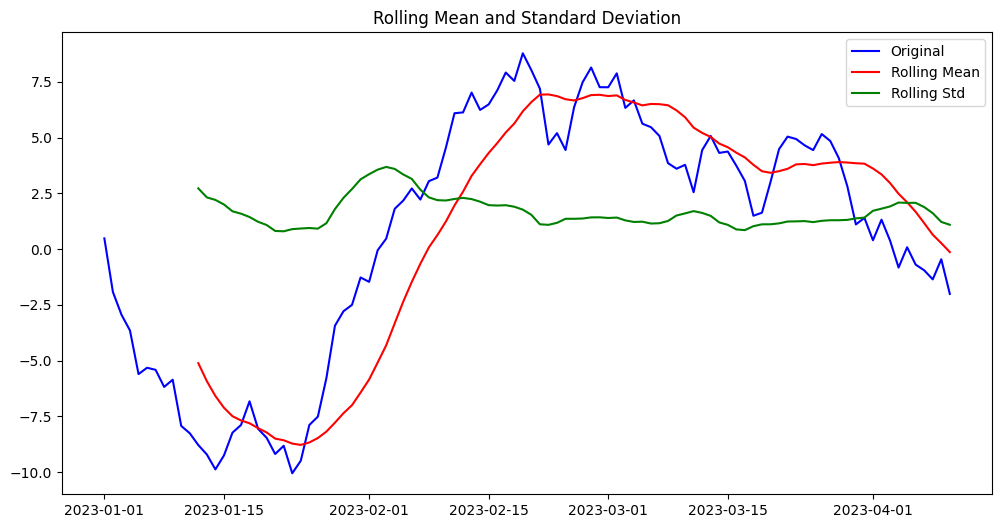

In [25]:
# Call the function with the desired column
test_stationarity(data['High'])

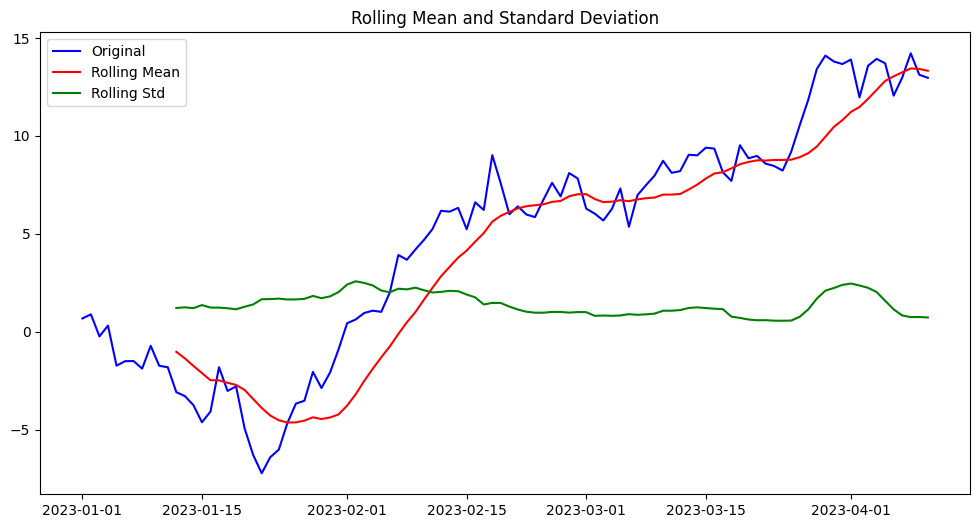

In [26]:
# Call the function with the desired column
test_stationarity(data['Low'])

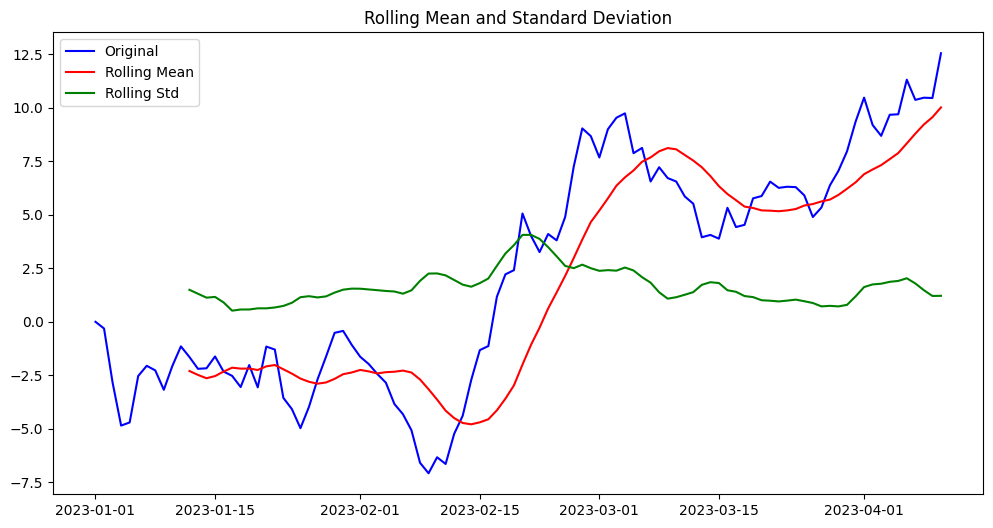

In [27]:
# Call the function with the desired column
test_stationarity(data['Close'])

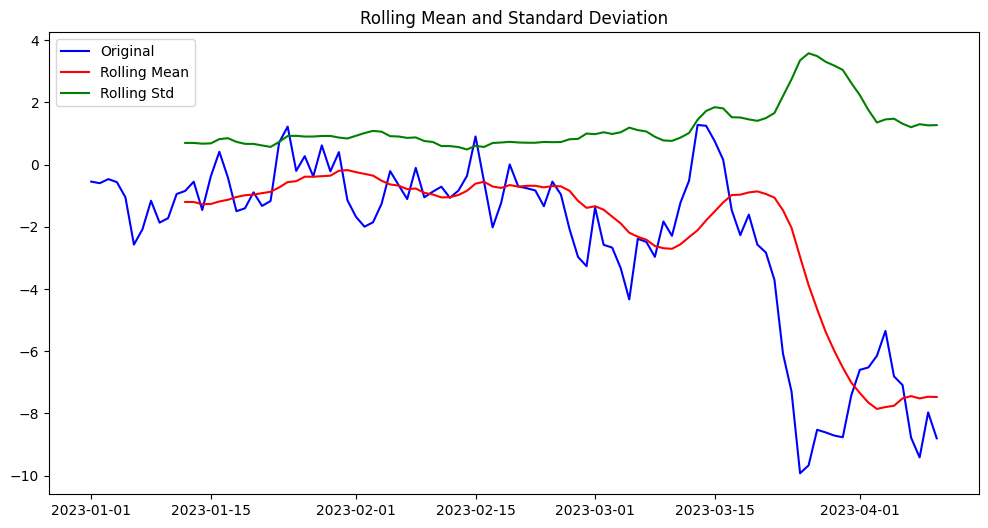

In [28]:
# Call the function with the desired column
test_stationarity(data['Volume'])

In [30]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

def adf_test(timeseries):
    # Perform the ADF test
    adf_result = adfuller(timeseries)

    # Create the output Series
    output = pd.Series(adf_result[0:4], index=['Test Statistic', 'p-value', '# Lags Used', 'Number of Observations'])
    for key, value in adf_result[4].items():
        output[f'Critical Value ({key})'] = value
    return output

# Create example data (replace with your actual time series)
data = pd.DataFrame({
    'Date': pd.date_range(start='2023-01-01', periods=100, freq='D'),
    'Open': np.random.randn(100).cumsum(),
    'High': np.random.randn(100).cumsum(),
    'Low': np.random.randn(100).cumsum(),
    'Close': np.random.randn(100).cumsum(),
    'Volume': np.random.randn(100).cumsum()
})

In [31]:
# Test multiple columns
results = {}
for column in data.columns:
    results[column] = adf_test(data[column])

# Print results for each column
for column, result in results.items():
    print(f"Results for {column}:\n{result}\n")

Results for Date:
Test Statistic             0.002144
p-value                    0.958709
# Lags Used                6.000000
Number of Observations    93.000000
Critical Value (1%)       -3.502705
Critical Value (5%)       -2.893158
Critical Value (10%)      -2.583637
dtype: float64

Results for Open:
Test Statistic            -2.824484
p-value                    0.054861
# Lags Used                0.000000
Number of Observations    99.000000
Critical Value (1%)       -3.498198
Critical Value (5%)       -2.891208
Critical Value (10%)      -2.582596
dtype: float64

Results for High:
Test Statistic            -1.539016
p-value                    0.514130
# Lags Used                0.000000
Number of Observations    99.000000
Critical Value (1%)       -3.498198
Critical Value (5%)       -2.891208
Critical Value (10%)      -2.582596
dtype: float64

Results for Low:
Test Statistic             1.709071
p-value                    0.998151
# Lags Used                1.000000
Number of Observa

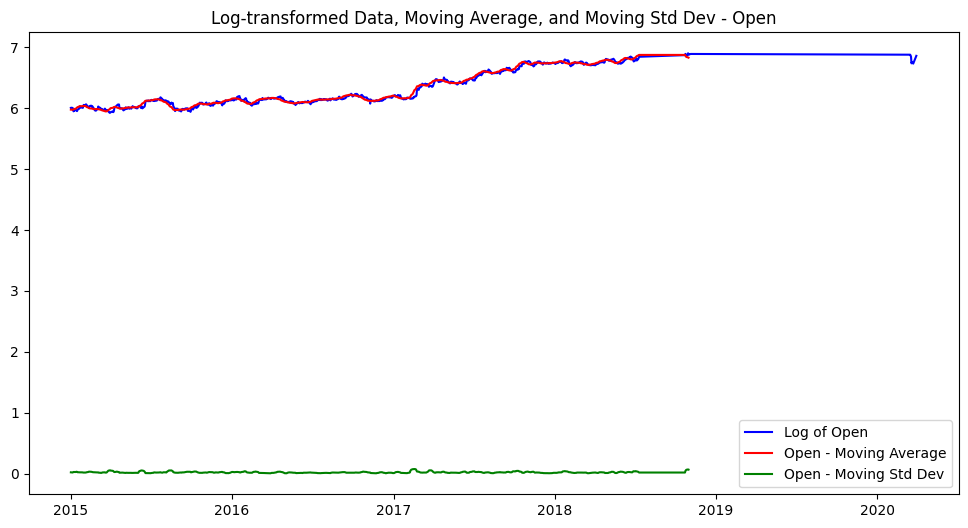

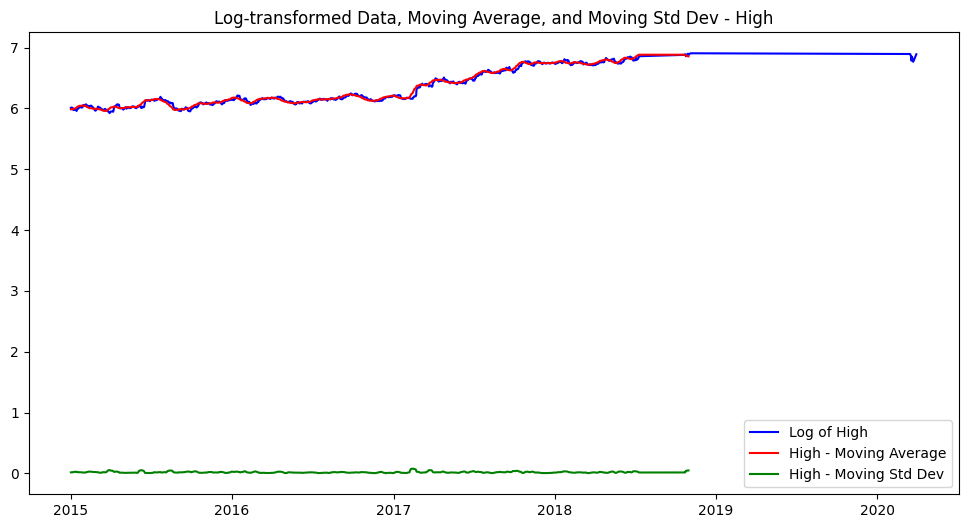

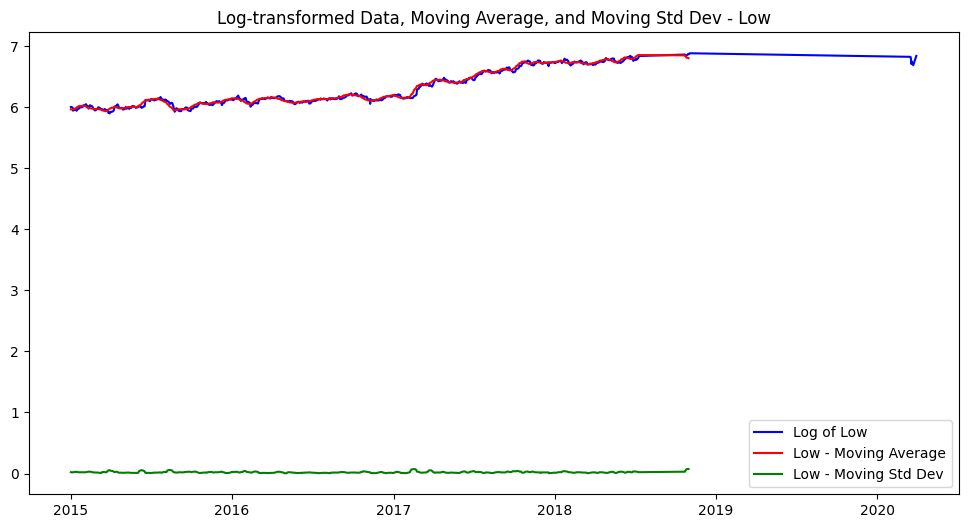

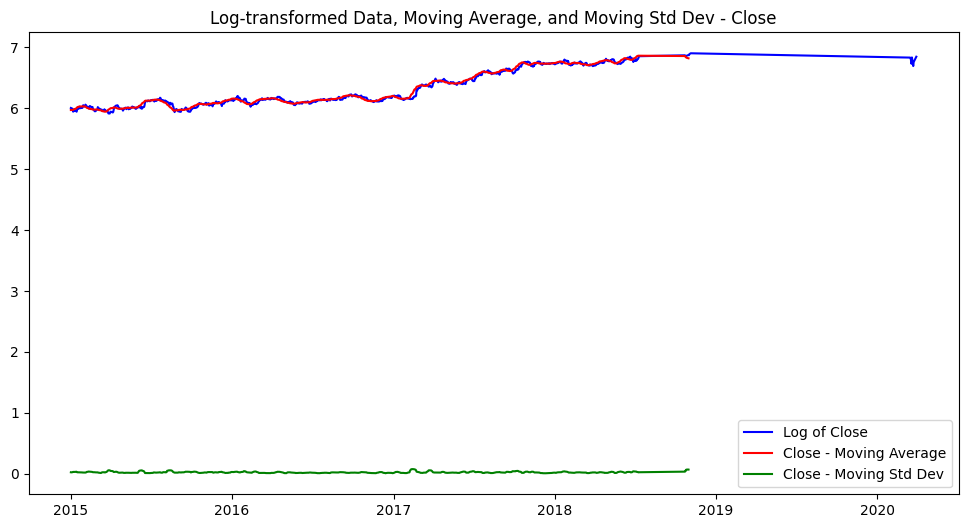

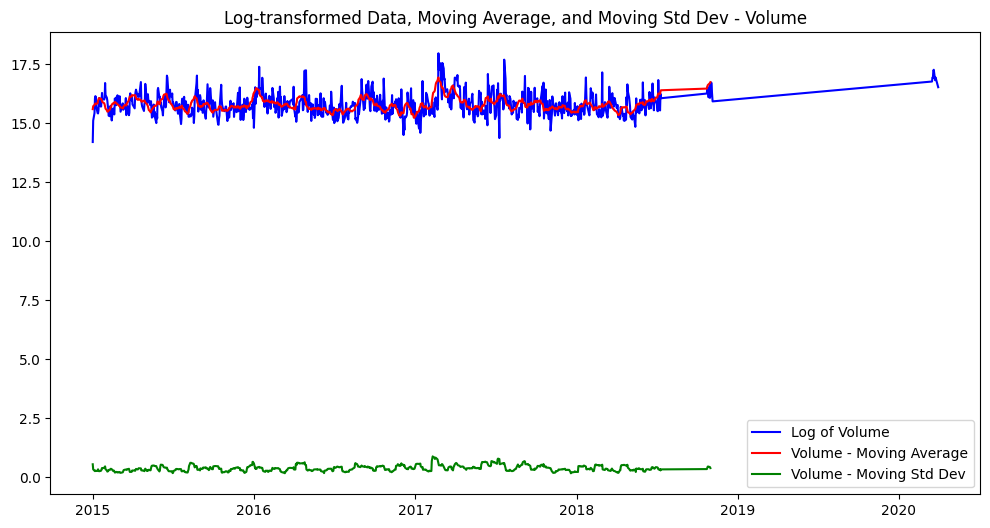

In [32]:
moving_avg=log_data.rolling(window=12).mean()
moving_std=log_data.rolling(window=12).std()
# Plot each column
for column in columns:
    plt.figure(figsize=(12, 6))
    plt.plot(log_data[column], label=f'Log of {column}', color='blue')
    plt.plot(moving_avg[column], color='red', label=f'{column} - Moving Average')
    plt.plot(moving_std[column], color='green', label=f'{column} - Moving Std Dev')
    plt.title(f'Log-transformed Data, Moving Average, and Moving Std Dev - {column}')
    plt.legend(loc='best')
    plt.show()

In [33]:
data_log_diff= log_data-moving_avg
data_log_diff.head(15)

,Open,High,Low,Close,Volume
Date,,,,,
2020-03-30,NaN,NaN,NaN,NaN,NaN
2020-03-24,NaN,NaN,NaN,NaN,NaN
2020-03-23,NaN,NaN,NaN,NaN,NaN
2020-03-20,NaN,NaN,NaN,NaN,NaN
2020-03-19,NaN,NaN,NaN,NaN,NaN
2020-03-18,NaN,NaN,NaN,NaN,NaN
2020-03-17,NaN,NaN,NaN,NaN,NaN
2020-03-16,NaN,NaN,NaN,NaN,NaN
2018-11-05,NaN,NaN,NaN,NaN,NaN


In [34]:
#Removing NAN values
data_log_diff.dropna(inplace=True)
data_log_diff

,Open,High,Low,Close,Volume
Date,,,,,
2018-10-31,0.047100,0.025658,0.064460,0.055720,-0.040650
2018-10-30,0.068295,0.043104,0.066734,0.049582,-0.628379
2018-10-26,0.009873,0.009338,0.026725,0.029556,-0.518010
2018-10-25,0.002635,-0.013846,0.008810,0.003165,-0.066339
2018-10-24,0.028279,0.016274,0.014831,0.015319,-0.035450
...,...,...,...,...,...
2015-01-07,-0.030923,-0.018684,-0.018753,-0.013286,0.312347
2015-01-06,0.010926,0.000937,-0.020127,-0.030201,0.226040
2015-01-05,0.029890,0.023121,0.030938,0.019130,-0.341929


In [35]:
from statsmodels.tsa.stattools import adfuller

# Perform the ADF test on each column of log-differenced data
print('Results of Dickey-Fuller Test for each column:')
for column in data_log_diff.columns:
    # Perform ADF test
    result = adfuller(data_log_diff[column])  # Ensure no NaNs
    # Create the output Series for log-differenced data
    my_output_diff = pd.Series(result[0:4], index=['Test Statistic', 'p-value', '# Lags Used', 'Number of Observations'])
    # Add critical values to the output for log-differenced data
    for key, value in result[4].items():
        my_output_diff[f'Critical Value ({key})'] = value

    # Print the output for each column
    print(f'\nResults for {column}:')
    print(my_output_diff)


Results of Dickey-Fuller Test for each column:

Results for Open:
Test Statistic           -9.293944e+00
p-value                   1.159649e-15
# Lags Used               4.000000e+00
Number of Observations    8.730000e+02
Critical Value (1%)      -3.437863e+00
Critical Value (5%)      -2.864856e+00
Critical Value (10%)     -2.568536e+00
dtype: float64

Results for High:
Test Statistic           -9.015219e+00
p-value                   5.975927e-15
# Lags Used               5.000000e+00
Number of Observations    8.720000e+02
Critical Value (1%)      -3.437871e+00
Critical Value (5%)      -2.864860e+00
Critical Value (10%)     -2.568538e+00
dtype: float64

Results for Low:
Test Statistic           -9.246915e+00
p-value                   1.528632e-15
# Lags Used               3.000000e+00
Number of Observations    8.740000e+02
Critical Value (1%)      -3.437854e+00
Critical Value (5%)      -2.864853e+00
Critical Value (10%)     -2.568534e+00
dtype: float64

Results for Close:
Test Statisti

In [40]:
data_log_diff.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

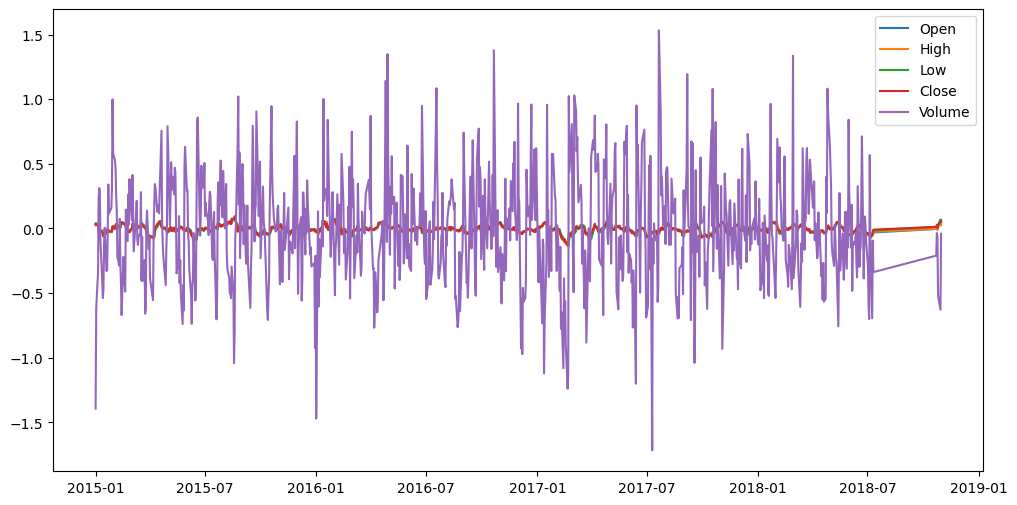

In [43]:
plt.figure(figsize=(12,6))

# Plot each column in data_log_diff with its name as the label
for column in data_log_diff.columns:
    plt.plot(data_log_diff[column], label=column)

plt.legend()
plt.show()
